Machine Learning / Advanced Analysis

# # Response‑Time Regression: Predict Student Answer Times
# This notebook walks through a step‑by‑step pipeline to predict how long a student will take to answer a question using the EdNet dataset.
# **Goal:** Build regression models (Random Forest, XGBoost, and MLP) to predict response time.
**Approach:**
1. Load and merge cleaned KT1–KT4 data.
2. Feature engineering: past average time per part, time‑of‑day, question difficulty.
3. Train/test split stratified by question part.
4. Model training with pipelines.
5. Evaluation using RMSE and MAE.

In [56]:
# 1. Imports and Setup
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Dense, Flatten, Concatenate, Dropout
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import RandomizedSearchCV



In [57]:
# 2. Load and Merge Data
data = pd.read_parquet('EdNet_full_log.parquet')
print(f"Initial data shape: {data.shape}")

# Merge in question metadata (bundle_id and part) from questions.csv
questions = pd.read_csv('questions.csv', usecols=['question_id', 'bundle_id', 'part'])

# Ensure matching types
# If question_id in data is string prefixed with 'q', strip; otherwise, cast as needed
# questions['question_id'] = questions['question_id'].str.lstrip('q')  # uncomment if needed
# data['question_id'] = data['question_id'].astype(str)

data = data.merge(questions, on='question_id', how='left')
print("After merge shape:", data.shape)
print(data[['question_id','bundle_id','part']].drop_duplicates().head())

Initial data shape: (32518836, 13)
After merge shape: (32518836, 15)
   question_id bundle_id  part
0         None       NaN   NaN
6        q5012     b3544   5.0
16       q4706     b3238   5.0
26       q4366     b2898   5.0
36       q4829     b3361   5.0


In [ ]:
# 3. Feature Engineering

## 3.1 Past Average Response Time per Part
# Compute per-student, per-part average elapsed_time
avg_time = (
    data.groupby(['user_id', 'part'])['elapsed_time']
        .mean()
        .reset_index()
        .rename(columns={'elapsed_time':'avg_time_per_part'})
)
# Merge back
data = data.merge(avg_time, on=['user_id','part'], how='left')

## 3.2 Time‑of‑Day and Categorical Encoding
# Create tod_idx & bundle_idx
data['hour'] = pd.to_datetime(data['timestamp'], unit='ms').dt.hour
data['time_of_day'] = pd.cut(data['hour'], bins=[0,6,12,18,24], labels=['night','morning','afternoon','evening'])
data['tod_idx']    = LabelEncoder().fit_transform(data['time_of_day'].astype(str))
data['bundle_idx'] = LabelEncoder().fit_transform(data['bundle_id'].astype(str))

# 3.3 Now drop rows missing any of those new columns
required_cols = ['elapsed_time','avg_time_per_part','tod_idx','bundle_idx','part']
data = data.dropna(subset=required_cols).reset_index(drop=True)

## 3.3 Prepare X, y and split
features = ['avg_time_per_part','tod_idx','bundle_idx']
target   = 'elapsed_time'
X = data[features]
y = data[target]

In [ ]:
#5. Train/Test Split
# Stratify by question part to maintain distribution

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=data['part']
)

# 5. Traditional Models (Random Forest & XGBoost)

In [ ]:
# 5.1 Preprocessing Pipeline
numeric_features = ['avg_time_per_part']
categorical_features = ['tod_idx','bundle_idx']

numeric_transformer = Pipeline([('scaler', StandardScaler())])
categorical_transformer = Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [ ]:
# 5.2 Define Pipelines
pipeline_rf = Pipeline([('preproc', preprocessor),('rf', RandomForestRegressor(random_state=42))])
pipeline_xgb = Pipeline([('preproc', preprocessor),('xgb', XGBRegressor(objective='reg:squarederror', random_state=42))])

param_dist = {
    'rf__n_estimators': [50, 100, 200, 300],
    'rf__max_depth': [None, 5, 10, 20],
    'rf__min_samples_split': [2, 5, 10]
}




In [ ]:
# 5.3 Hyperparameter Tuning for Random Forest
# Use randomized search instead of full GridSearchCV (would not complete run time on too large dataset)

# Subsample 30% to speed up tuning
X_sub, _, y_sub, _ = train_test_split(
    X_train, y_train,
    train_size=0.3,
    random_state=42,
)

rand_rf = RandomizedSearchCV(
    pipeline_rf,
    param_distributions=param_dist,
    n_iter=8,            # try only 8 combos
    cv=2,                # 2‑fold CV
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

print("Tuning Random Forest with RandomizedSearchCV...")
rand_rf.fit(X_sub, y_sub)
print("Best RF params:", rand_rf.best_params_)

Tuning Random Forest with RandomizedSearchCV...
Best RF params: {'rf__n_estimators': 50, 'rf__min_samples_split': 2, 'rf__max_depth': 5}


In [ ]:
# 5.4 XGBoost Baseline

pipeline_xgb = Pipeline([('preproc', preprocessor),
                          ('xgb', XGBRegressor(objective='reg:squarederror', random_state=42))])
pipeline_xgb.fit(X_train, y_train)

,steps,"[('preproc', ...), ('xgb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
### 5.4 Evaluate RF and XGBoost
rfs_pred = best_rf.predict(X_test)
rfx_rmse = np.sqrt(mean_squared_error(y_test, rfs_pred))
rfx_mae = mean_absolute_error(y_test, rfs_pred)

xgb_pred = pipeline_xgb.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mae = mean_absolute_error(y_test, xgb_pred)

print(f"Random Forest - RMSE: {rfx_rmse:.2f}, MAE: {rfx_mae:.2f}")
print(f"XGBoost       - RMSE: {xgb_rmse:.2f}, MAE: {xgb_mae:.2f}")



Random Forest - RMSE: 22375.69, MAE: 9092.56
XGBoost       - RMSE: 22048.20, MAE: 8782.49


## 6. MLP Regression with Keras


In [ ]:
### 6.1 Input Layers and Embeddings
i_input = Input(shape=(1,), name='avg_time')
tod_input = Input(shape=(1,), name='tod')
embed_tod = Embedding(input_dim=data['tod_idx'].nunique(), output_dim=4)(tod_input)
bundle_input = Input(shape=(1,), name='bundle')
embed_bundle = Embedding(input_dim=data['bundle_idx'].nunique(), output_dim=16)(bundle_input)
flat_tod = Flatten()(embed_tod)
flat_bundle = Flatten()(embed_bundle)
concat = Concatenate()([i_input, flat_tod, flat_bundle])

In [ ]:
### 6.2 MLP Architecture

d = Dense(64, activation='relu')(concat)
d = Dropout(0.3)(d)
d = Dense(32, activation='relu')(d)
d = Dropout(0.2)(d)
d = Dense(16, activation='relu')(d)
output = Dense(1, name='elapsed_time')(d)
model = Model([i_input, tod_input, bundle_input], output)
model.compile(optimizer='adam', loss='mse', metrics=[tf.keras.metrics.RootMeanSquaredError(), 'mae'])
model.summary()



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tod (InputLayer)    │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bundle (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 4)      │         20 │ tod[0][0]         │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 16)     │    139,104 │ bundle[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ avg_time            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 4)         │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 16)        │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 21)        │          0 │ avg_time[0][0],   │
│ (Concatenate)       │                   │            │ flatten[0][0],    │
│                     │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      1,408 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │        528 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ elapsed_time        │ (None, 1)         │         17 │ dense_2[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 143,157 (559.21 KB)

 Trainable params: 143,157 (559.21 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
### 6.3 Train MLP

train_inputs = {
    'avg_time': X_train['avg_time_per_part'],
    'tod': X_train['tod_idx'],
    'bundle': X_train['bundle_idx']
}
history = model.fit(
    train_inputs, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=1024,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)]
)

Epoch 1/20
767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 647873664.0000 - mae: 11870.9365 - root_mean_squared_error: 25281.9453 - val_loss: 528488288.0000 - val_mae: 9522.0645 - val_root_mean_squared_error: 22988.8730
Epoch 2/20
767/767 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 504576992.0000 - mae: 9442.9941 - root_mean_squared_error: 22459.0527 - val_loss: 554488768.0000 - val_mae: 10230.5801 - val_root_mean_squared_error: 23547.5859
Epoch 3/20
767/767 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 514771904.0000 - mae: 9372.3945 - root_mean_squared_error: 22682.4746 - val_loss: 591955776.0000 - val_mae: 11227.2217 - val_root_mean_squared_error: 24330.1406
Epoch 4/20
767/767 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 518661568.0000 - mae: 9277.2744 - root_mean_squared_error: 22759.4766 - val_loss: 579417216.0000 - val_mae: 10904.4238 - val_root_mean_squared_error: 24071.0859


In [ ]:
### 6.4 Evaluate MLP

mlp_pred = model.predict({
    'avg_time': X_test['avg_time_per_part'],
    'tod': X_test['tod_idx'],
    'bundle': X_test['bundle_idx']
}).flatten()
mlp_rmse = np.sqrt(mean_squared_error(y_test, mlp_pred))
mlp_mae = mean_absolute_error(y_test, mlp_pred)
print(f"MLP - RMSE: {mlp_rmse:.2f}, MAE: {mlp_mae:.2f}")



# %% [markdown]
## 7. Conclusions and Next Steps
# - Compare RMSE/MAE across all models.
# - Analyze residuals by part/time_of_day.
# - Tune embedding sizes and network depth.
# - Investigate sequence models if needed.

13148/13148 ━━━━━━━━━━━━━━━━━━━━ 6s 484us/step
MLP - RMSE: 22980.15, MAE: 9523.70


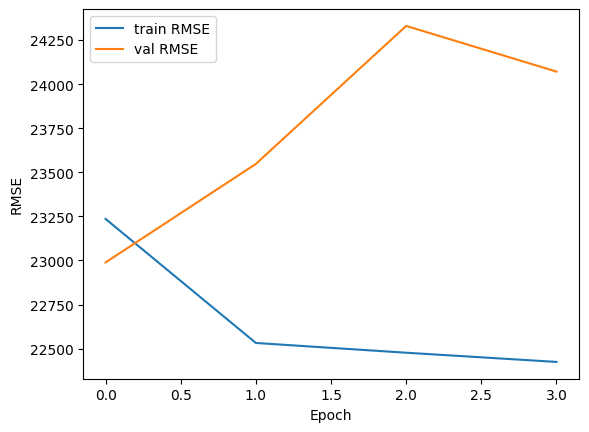

In [ ]:
### 6.5 Plot Training Curves
plt.figure()
plt.plot(history.history['root_mean_squared_error'], label='train RMSE')
plt.plot(history.history['val_root_mean_squared_error'], label='val RMSE')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.legend()
plt.show()